# Random Forest

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

In [1]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

In [2]:
# import layers and combine in one dataset
ds = xr.Dataset({
    "study_area": rxr.open_rasterio('output-data/study-area/study_area.tif'),
    # predictors
    "hfp": rxr.open_rasterio('output-data/predictor-layers/hfp.tif'),
    "drainage_dist": rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif"),
    "forest_dist": rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif"),
    "pre_fire_evi": rxr.open_rasterio("output-data/predictor-layers/evi_pre.tif"),
    'aridity_index': rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif'),
    'fire_history': rxr.open_rasterio('output-data/predictor-layers/fire_count.tif'),
    'dnbr': rxr.open_rasterio('output-data/predictor-layers/dnbr.tif'),
    'elevation': rxr.open_rasterio('output-data/predictor-layers/elevation.tif'),
    # target variables
    # 'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017.tif"),
    # 'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020.tif")
    'recovery_2y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2017_no_neg.tif"),
    'recovery_5y': rxr.open_rasterio("output-data/target-variables/recovery_rate_2020_no_neg.tif")
})

In [3]:
# transform to pandas dataframe (only study area pixels)
df = ds.to_dataframe().reset_index()

# remove pixels outside study area
df = df[df.study_area == 1]

# drop unnecessary columns
df = df.drop(['band', 'spatial_ref', 'study_area'], axis='columns')

In [4]:
# check data availability
df.info()

<class 'pandas.DataFrame'>
Index: 17989 entries, 1643330 to 15897535
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   x              17989 non-null  float64
 1   y              17989 non-null  float64
 2   hfp            17989 non-null  uint8  
 3   drainage_dist  17989 non-null  float64
 4   forest_dist    17989 non-null  float64
 5   pre_fire_evi   17989 non-null  float64
 6   aridity_index  17989 non-null  float64
 7   fire_history   17989 non-null  uint16 
 8   dnbr           17989 non-null  float64
 9   elevation      17989 non-null  int16  
 10  recovery_2y    16624 non-null  float64
 11  recovery_5y    16306 non-null  float64
dtypes: float64(9), int16(1), uint16(1), uint8(1)
memory usage: 1.5 MB


In [5]:
# remove rows with nans
df = df.dropna()

In [8]:
# check remaining pixels
len(df)

15842

## Data exploration

<Axes: >

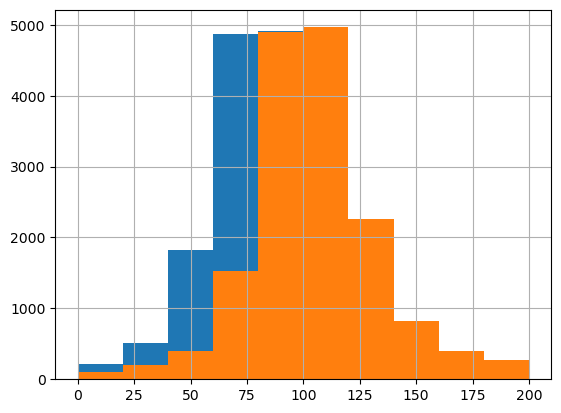

In [9]:
# histograms of predictors and target metrics
df.recovery_2y.hist()
df.recovery_5y.hist()

In [10]:
df.recovery_2y.mean()

np.float64(83.4295484905763)

In [12]:
np.std(df.recovery_2y)

27.5694575318121

## Model fitting

In [142]:
# make list with predictor column names
predictor_cols = df.columns.to_list()[2:-2]
predictor_cols

['hfp',
 'drainage_dist',
 'forest_dist',
 'pre_fire_evi',
 'aridity_index',
 'fire_history',
 'dnbr',
 'elevation']

In [143]:
# set up predictors = response
X = df[predictor_cols]
y_2y = df.recovery_2y
y_5y = df.recovery_5y

In [144]:
# prepare 10-fold cross-validation (CV)
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict

kf = KFold(n_splits=10, 
           shuffle=True, # randomly shuffle order before making folds
           random_state=42)

In [145]:
# prepare models
from sklearn.ensemble import RandomForestRegressor

rf_2y = RandomForestRegressor(
    n_estimators=200, # number of trees 
    max_features=len(predictor_cols)-1, # number of features at each split (all, because low total number)
    random_state=42,
    n_jobs=-1
)

rf_5y = RandomForestRegressor(
    n_estimators=200,
    max_features=len(predictor_cols)-1, 
    random_state=42,
    n_jobs=-1
)

In [146]:
# predict per fold (out of box)

y_2y_pred = cross_val_predict(rf_2y, X, y_2y, cv=kf, n_jobs=-1)
df.loc[:, 'pred_2y'] = y_2y_pred
df['resid_pred_2y'] = df.recovery_2y - df.pred_2y

y_5y_pred = cross_val_predict(rf_2y, X, y_5y, cv=kf, n_jobs=-1)
df.loc[:, 'pred_5y'] = y_5y_pred
df['resid_pred_5y'] = df.recovery_5y - df.pred_5y

## Model accuracy

In [147]:
# r2, rmse, mae
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2_2y = r2_score(df.recovery_2y, df.pred_2y)
rmse_2y = np.sqrt(mean_squared_error(df.recovery_2y, df.pred_2y))
mae_2y = mean_absolute_error(df.recovery_2y, df.pred_2y)

print(r2_2y)
print(rmse_2y)
print(mae_2y)

0.4778063500216858
19.922508189317405
13.220663150963368


In [148]:
r2_5y = r2_score(df.recovery_5y, df.pred_5y)
rmse_5y = np.sqrt(mean_squared_error(df.recovery_5y, df.pred_5y))
mae_5y = mean_absolute_error(df.recovery_5y, df.pred_5y)

print(r2_5y)
print(rmse_5y)
print(mae_5y)

0.43910378653194393
21.104169888618824
14.150377196127097


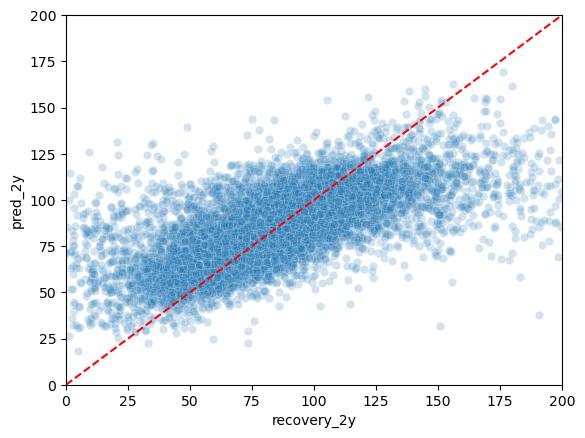

In [150]:
# scatterplot + correlation coefficient
sns.scatterplot(x=df.recovery_2y, y=df.pred_2y, alpha=.2)
plt.axline(xy1=(0,0), slope=1, color='red', linestyle='--')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.show()

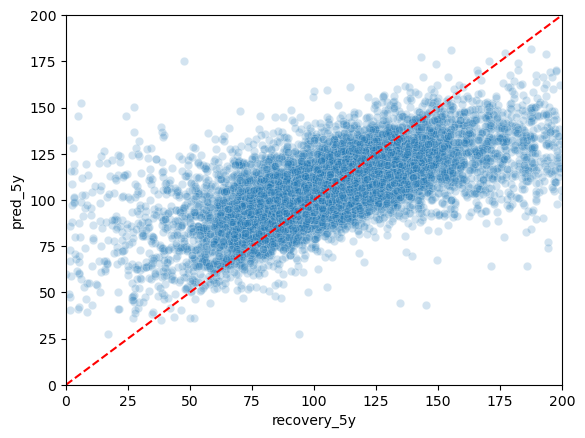

In [151]:
# scatterplot + correlation coefficient
sns.scatterplot(x=df.recovery_5y, y=df.pred_5y, alpha=.2)
plt.axline(xy1=(0,0), slope=1, color='red', linestyle='--')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.show()

## Variable importance

In [152]:
# train models on full data (for next steps)
rf_2y.fit(X, y_2y)
rf_5y.fit(X, y_5y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [153]:
# 2 years
importances = rf_2y.feature_importances_

importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,variable,importance
4,aridity_index,0.196212
3,pre_fire_evi,0.183300
1,drainage_dist,0.173266
6,dnbr,0.161248
2,forest_dist,0.113342
7,elevation,0.072475
0,hfp,0.051689
5,fire_history,0.048469


In [154]:
# 5 years
importances = rf_5y.feature_importances_

importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,variable,importance
4,aridity_index,0.197027
6,dnbr,0.172311
1,drainage_dist,0.163421
3,pre_fire_evi,0.156124
2,forest_dist,0.136222
7,elevation,0.071186
5,fire_history,0.052466
0,hfp,0.051243


## Variable effects (partial dependence)

In [64]:
from sklearn.inspection import PartialDependenceDisplay

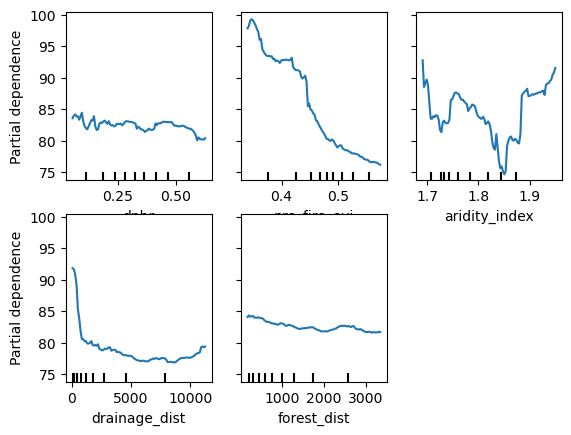

In [155]:
# 2 years
PartialDependenceDisplay.from_estimator(
    rf_2y,
    X,
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist']
)

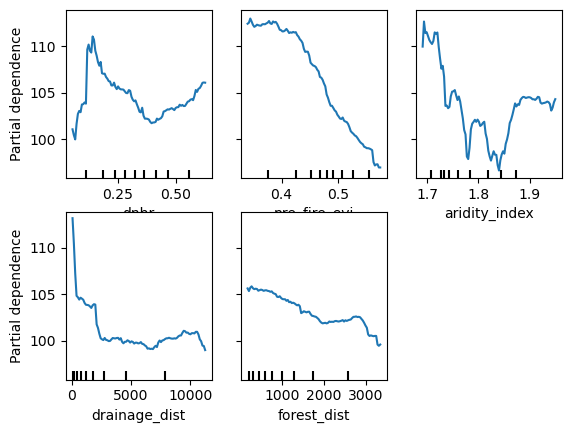

In [156]:
# 5 years
PartialDependenceDisplay.from_estimator(
    rf_5y,
    X,
    ['dnbr', 'pre_fire_evi', 'aridity_index', 'drainage_dist', 'forest_dist']
)